#### 로지스틱 회귀
```
공부한 시간  데이터를 복? 합격(여부를 예측)
공부시간에 비례해서 점수를 부여
공부 1시간에 10점을 부여
--> 선형 방정식
합격점수(z) = w*(공부시간) + b
W(가중치) : 중요도 1시간 당 점수(10점)
b(편향) : 기본점수(-50, 5시간)

문제점 : 합격점수에 해당하는 100점이 나올수도 있지만 -200점이 나올수도 있다.
분류를 할려면 합격 , 불합격을 판단해야하는 데 그러기위해 필요한것은 확률
방정식의 값으로 확률을 계산(0% ~ 100%)
```

#### 점수를 확률로 바꿔야 한다. (시그모이드 함수) 0~1사이의 확률 값으로 변경
```
합격확률 = 시그모이드(z) = 1 / 1 + e^-z
합격점수가 높으면 1에 가깝고
낮으면 0에 가깝다.
합격점수가 0이면 정확히 0.5(50%) - 임계값
```

#### 비용함수(손실함수) : 모델이 얼마나 틀렸는지 측정 로지스틱은 로그함수를 사용
```
합격(정답=1)
모델이 99% 합격예측 == > 벌점은 거의 0점
모델이 1% 합격예측 == > 벌점은 크게(무한대에 가깝게)

불합격(정답 = 0)
모델이 1%로 합격을 예측 -> 잘 맞춤 벌점이 거의 0점
모델이 99%로 합격을 예측 -> 완전 틀림 벌점을 아주크게

log loss 원리 
w,b를 찾음... 손실함수를 이용해서 비용이 가장낮을때 
```

##### 비용이 최저인 값을 찾아나가는 과정 : 경사하강법
##### 너무 완벽한 모델..(학습에 대해서)
```
규제(Regularozation) 모델이 너무 복잡해지지 않도록 패널티 혹은 중요도를 간결하게 설정한다.
L2규제(Ridge) : w(중요도) 값이 너무 커지는 것을 막는다. 가중치(w) 제곱의 합만큼 패널티 추가
L1규제(Lasso) : 어떤 특징이 별로 안중요할거 같은 w(중요도)를 그냥 0으로 만든다.
불필요한 특성을 제거한다.
가중치들의 절대값의 합을 패널티로 추가 - feature selecter 역활도 겸함 ^
```

![화면 캡처 2025-10-21 153659.png](<attachment:화면 캡처 2025-10-21 153659.png>)
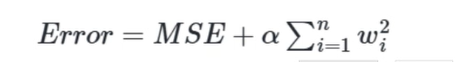

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,stratify=y)

clr = LogisticRegression(max_iter=10000)
clr.fit(x_train,y_train)
predict = clr.predict(x_test)
print(predict[:5],  y_test[:5])

# 모델이 제시한 값들에 대한 클래스 확률
predict_proba = clr.predict_proba(x_test)
predict_proba[:5]

[1 0 1 0 1] [1 0 1 0 1]
